# Clasificador de Intenciones - Entorno Controlado

Este notebook construye y compara dos modelos de clasificación de texto:
- **Multinomial Naive Bayes (NB)**
- **Support Vector Machine lineal (SVM)**

Objetivo: clasificar frases en 4 intenciones:
`URGENTE`, `SOPORTE`, `COMPRAS`, `SALUDO`.

Todo el flujo es reproducible y no depende de fuentes externas.

## 0) Imports y configuración

En esta celda cargamos librerías base y fijamos semilla para reproducibilidad.

In [3]:
import random
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

sns.set(style="whitegrid")
pd.set_option("display.max_colwidth", 120)

## 1) Generación de datos sintéticos

Creamos 200 frases balanceadas en español (50 por categoría):
- `URGENTE`
- `SOPORTE`
- `COMPRAS`
- `SALUDO`

In [4]:
urgente_texts = [
    "es urgente necesito ayuda ahora",
    "tengo una emergencia con el servicio",
    "prioridad alta por favor responder ya",
    "problema critico necesito solucion inmediata",
    "requiero atencion urgente hoy mismo",
    "se cayo el sistema y es urgente",
    "no puedo operar necesito soporte urgente",
    "incidencia grave resolver en este momento",
    "es un caso urgente para el equipo",
    "por favor atiendan esto de inmediato",
    "urgente no funciona la plataforma",
    "hay un bloqueo total necesito ayuda ya",
    "situacion critica con el acceso",
    "me urge restablecer el servicio",
    "error severo necesito respuesta rapida",
    "esto es muy urgente para mi area",
    "fallo critico en produccion",
    "resolver urgente antes de la reunion",
    "atencion inmediata por favor",
    "prioridad uno necesito soporte",
    "urgente se perdio la conexion",
    "necesito solucion ahora mismo",
    "incidente urgente en el sistema",
    "caso critico atender hoy",
    "por favor escalar esto urgente",
    "problema grave en mi cuenta",
    "necesito ayuda inmediata",
    "urgente error al iniciar sesion",
    "alto impacto requiere atencion ya",
    "me urge que revisen este fallo",
    "servicio caido atencion inmediata",
    "incidencia prioritaria resolver hoy",
    "urgente no puedo continuar trabajando",
    "se detuvo el proceso critico",
    "necesito respuesta urgente",
    "hay una falla mayor",
    "urgente no carga el portal",
    "bloqueo critico en la operacion",
    "caso de maxima prioridad",
    "favor de atender urgente",
    "error critico en facturacion",
    "servicio interrumpido resolver ya",
    "urgente sin acceso al sistema",
    "falla importante necesito apoyo ya",
    "sistema inestable atencion urgente",
    "urgencia operativa en curso",
    "resolver de inmediato este caso",
    "prioridad critica para negocio",
    "incidente de alta urgencia",
    "necesito soporte urgente ahora"
]

soporte_texts = [
    "necesito soporte tecnico para mi cuenta",
    "pueden ayudarme con este error",
    "como configuro la aplicacion correctamente",
    "tengo dudas sobre el funcionamiento",
    "requiero asistencia para instalar el sistema",
    "el modulo no responde necesito soporte",
    "me explican como recuperar mi usuario",
    "ayuda con la configuracion del perfil",
    "tengo un problema tecnico recurrente",
    "podrian orientarme con este inconveniente",
    "necesito soporte para integrar la api",
    "como soluciono el fallo de autenticacion",
    "me apoyan con un tema de permisos",
    "quiero reportar un bug del panel",
    "ayuda para actualizar la aplicacion",
    "tengo errores al cargar archivos",
    "soporte para sincronizar datos",
    "me pueden guiar paso a paso",
    "no entiendo este mensaje de error",
    "requiere soporte la funcionalidad de pagos",
    "asistencia para restablecer contraseña",
    "soporte sobre la conexion con el servidor",
    "necesito ayuda con la integracion",
    "como habilito notificaciones en la cuenta",
    "fallo al exportar reporte necesito soporte",
    "me sale un error al guardar",
    "ayuda tecnica con el dashboard",
    "podrian revisar este comportamiento",
    "necesito soporte sobre acceso de usuarios",
    "me orientan con el proceso de alta",
    "tengo dudas tecnicas del sistema",
    "soporte para resolver error de carga",
    "como corregir problema de rendimiento",
    "requiero asistencia tecnica",
    "me ayudan a configurar alertas",
    "soporte para activar una funcionalidad",
    "como recupero informacion eliminada",
    "tengo inconvenientes con la plataforma",
    "ayuda para entender la documentacion",
    "necesito soporte funcional",
    "error en el formulario de registro",
    "podrian ayudar con un ajuste",
    "soporte para problema de compatibilidad",
    "como soluciono este bug",
    "tengo una incidencia tecnica menor",
    "asistencia para parametrizar el sistema",
    "me apoyan con el entorno de pruebas",
    "quiero soporte para mi usuario",
    "requiero ayuda tecnica en general",
    "necesito soporte con el modulo"
]

compras_texts = [
    "quiero conocer el precio del plan premium",
    "me interesa comprar una licencia anual",
    "podrian enviar cotizacion del servicio",
    "cual es el costo de la suscripcion",
    "necesito informacion para realizar una compra",
    "quiero adquirir el paquete empresarial",
    "tienen descuento por volumen",
    "me comparten los planes disponibles",
    "como hago el proceso de compra",
    "deseo contratar el servicio este mes",
    "consulta sobre precios y facturacion",
    "quiero renovar mi plan de pago",
    "me interesa el plan mas completo",
    "podemos hablar de una propuesta comercial",
    "solicito cotizacion para mi empresa",
    "costo por usuario al mes",
    "quiero comprar mas asientos",
    "informacion comercial de los paquetes",
    "precio del modulo adicional",
    "necesito presupuesto para el proyecto",
    "me interesa contratar soporte premium",
    "como pago la licencia",
    "consulta de compra para nuevo cliente",
    "requiero oferta comercial",
    "quiero conocer promociones vigentes",
    "cual es el valor del plan basico",
    "me ayudan con una cotizacion formal",
    "quiero adquirir el producto hoy",
    "proceso para comprar online",
    "precio de implementacion inicial",
    "me interesa plan corporativo",
    "como contratar una demo pagada",
    "deseo comprar el servicio anual",
    "consulta de facturacion y precios",
    "pueden enviar propuesta economica",
    "quiero ampliar mi plan",
    "solicito informacion de compra",
    "precio para 50 usuarios",
    "quiero cotizar integracion avanzada",
    "me interesa una oferta por tiempo limitado",
    "presupuesto para licencia completa",
    "quiero comprar una extension",
    "formas de pago disponibles",
    "necesito precio actualizado",
    "consulta comercial para adquisicion",
    "quiero contratar hoy",
    "solicitud de cotizacion urgente",
    "me interesa el costo total",
    "quiero comprar y activar ya",
    "informacion para cerrar la compra"
]

saludo_texts = [
    "hola buenos dias",
    "buenas tardes como estan",
    "hola equipo gracias por su ayuda",
    "que tal espero que esten bien",
    "saludos cordiales",
    "hola necesito orientacion general",
    "buen dia",
    "hola me presento soy cliente nuevo",
    "mucho gusto en contactarles",
    "hola hola",
    "buenas noches",
    "gracias y saludos",
    "hola quisiera hacer una consulta",
    "buenas quiero informacion general",
    "estimado equipo saludos",
    "hola como va todo",
    "que gusto saludarles",
    "hola amigos",
    "saludos y gracias",
    "hola por favor",
    "buenas tardes equipo",
    "hola necesito apoyo",
    "saludos buen dia",
    "hola tengo una duda",
    "buenos dias estimados",
    "hola que tal",
    "saludos cordiales equipo",
    "hola estoy aqui",
    "buenas tardes a todos",
    "hola excelente dia",
    "saludos",
    "hola buen dia equipo",
    "muchas gracias saludos",
    "hola me pueden escuchar",
    "buenas como les va",
    "hola hola buen dia",
    "saludos para todos",
    "hola me gustaria preguntar algo",
    "buenas tardes gracias",
    "hola cordial saludo",
    "hola espero su respuesta",
    "saludos atentos",
    "hola feliz dia",
    "buenas noches equipo",
    "hola solo queria saludar",
    "buenas tardes cordialmente",
    "hola y gracias",
    "saludos equipo de soporte",
    "hola encantado de escribirles",
    "buen dia a todos"
]

data = (
    [(txt, "URGENTE") for txt in urgente_texts] +
    [(txt, "SOPORTE") for txt in soporte_texts] +
    [(txt, "COMPRAS") for txt in compras_texts] +
    [(txt, "SALUDO") for txt in saludo_texts]
)

random.shuffle(data)
df = pd.DataFrame(data, columns=["texto", "etiqueta"])

print(f"Total de ejemplos: {len(df)}")
print("Distribución por clase:")
print(df["etiqueta"].value_counts())

df.head(8)

Total de ejemplos: 200
Distribución por clase:
etiqueta
SOPORTE    50
SALUDO     50
COMPRAS    50
URGENTE    50
Name: count, dtype: int64


,texto,etiqueta
0,soporte para sincronizar datos,SOPORTE
1,hola me gustaria preguntar algo,SALUDO
2,me interesa comprar una licencia anual,COMPRAS
3,buenas noches equipo,SALUDO
4,quiero renovar mi plan de pago,COMPRAS
5,como pago la licencia,COMPRAS
6,me urge restablecer el servicio,URGENTE
7,prioridad alta por favor responder ya,URGENTE


## 2) Preprocesamiento y pipeline

Definimos una función de limpieza con:
1. Conversión a minúsculas.
2. Remoción de signos y caracteres no alfanuméricos.
3. Eliminación de stopwords manuales en español (lista de 20 términos).

Luego usamos `TfidfVectorizer` para vectorizar el texto.

In [5]:
# Lista manual de stopwords (20 comunes)
stopwords_es = {
    "de", "la", "el", "y", "en", "a", "que", "los", "las", "por",
    "para", "con", "un", "una", "del", "al", "me", "mi", "es", "se"
}

def limpiar_texto(texto: str) -> str:
    """Limpia texto para clasificación en un escenario controlado."""
    texto = texto.lower()
    # Conservamos letras, números y espacios (incluyendo acentos y ñ)
    texto = re.sub(r"[^a-záéíóúüñ0-9\s]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    tokens = [t for t in texto.split() if t not in stopwords_es]
    return " ".join(tokens)

# Aplicamos limpieza al DataFrame

df["texto_limpio"] = df["texto"].apply(limpiar_texto)
df[["texto", "texto_limpio", "etiqueta"]].head(10)

,texto,texto_limpio,etiqueta
0,soporte para sincronizar datos,soporte sincronizar datos,SOPORTE
1,hola me gustaria preguntar algo,hola gustaria preguntar algo,SALUDO
2,me interesa comprar una licencia anual,interesa comprar licencia anual,COMPRAS
3,buenas noches equipo,buenas noches equipo,SALUDO
4,quiero renovar mi plan de pago,quiero renovar plan pago,COMPRAS
5,como pago la licencia,como pago licencia,COMPRAS
6,me urge restablecer el servicio,urge restablecer servicio,URGENTE
7,prioridad alta por favor responder ya,prioridad alta favor responder ya,URGENTE
8,ayuda para actualizar la aplicacion,ayuda actualizar aplicacion,SOPORTE
9,sistema inestable atencion urgente,sistema inestable atencion urgente,URGENTE


## 3) Entrenamiento comparativo (NB vs SVM)

Usamos un split 80/20 para entrenamiento y prueba.
- Modelo 1: `MultinomialNB`
- Modelo 2: `SVC` con kernel lineal y `probability=True`

In [6]:
X = df["texto_limpio"]
y = df["etiqueta"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

pipeline_nb = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", MultinomialNB())
])

pipeline_svm = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", SVC(kernel="linear", probability=True, random_state=SEED))
])

pipeline_nb.fit(X_train, y_train)
pipeline_svm.fit(X_train, y_train)

y_pred_nb = pipeline_nb.predict(X_test)
y_pred_svm = pipeline_svm.predict(X_test)

print(f"Tamaño train: {len(X_train)} | Tamaño test: {len(X_test)}")

Tamaño train: 160 | Tamaño test: 40


## 4) Evaluación visual

Generamos matrices de confusión para ambos modelos y mostramos `classification_report` detallado.

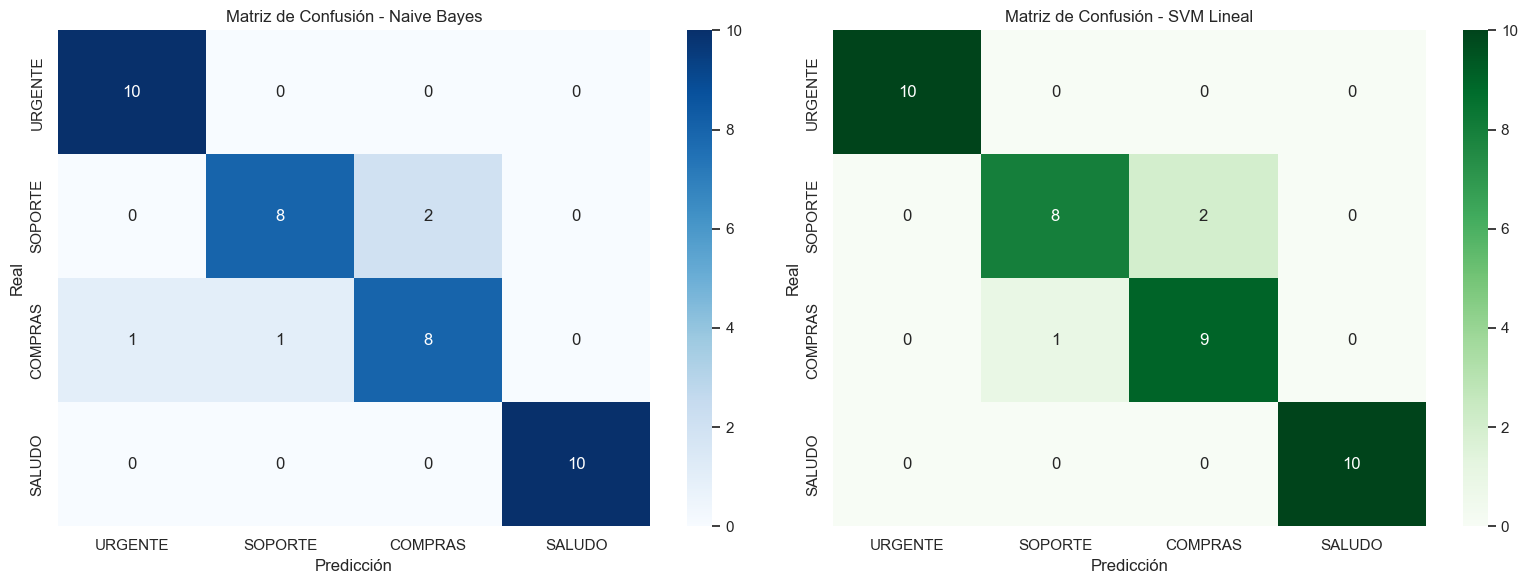

===== Classification Report - Naive Bayes =====
              precision    recall  f1-score   support

     COMPRAS       0.80      0.80      0.80        10
      SALUDO       1.00      1.00      1.00        10
     SOPORTE       0.89      0.80      0.84        10
     URGENTE       0.91      1.00      0.95        10

    accuracy                           0.90        40
   macro avg       0.90      0.90      0.90        40
weighted avg       0.90      0.90      0.90        40

===== Classification Report - SVM Lineal =====
              precision    recall  f1-score   support

     COMPRAS       0.82      0.90      0.86        10
      SALUDO       1.00      1.00      1.00        10
     SOPORTE       0.89      0.80      0.84        10
     URGENTE       1.00      1.00      1.00        10

    accuracy                           0.93        40
   macro avg       0.93      0.93      0.92        40
weighted avg       0.93      0.93      0.92        40



In [7]:
labels = ["URGENTE", "SOPORTE", "COMPRAS", "SALUDO"]

cm_nb = confusion_matrix(y_test, y_pred_nb, labels=labels)
cm_svm = confusion_matrix(y_test, y_pred_svm, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[0]
)
axes[0].set_title("Matriz de Confusión - Naive Bayes")
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Real")

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[1]
)
axes[1].set_title("Matriz de Confusión - SVM Lineal")
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Real")

plt.tight_layout()
plt.show()

report_nb_dict = classification_report(y_test, y_pred_nb, output_dict=True)
report_svm_dict = classification_report(y_test, y_pred_svm, output_dict=True)

report_nb_text = classification_report(y_test, y_pred_nb)
report_svm_text = classification_report(y_test, y_pred_svm)

print("===== Classification Report - Naive Bayes =====")
print(report_nb_text)
print("===== Classification Report - SVM Lineal =====")
print(report_svm_text)

## 5) Ejemplo de uso interactivo (DEMO)

Probamos un caso ambiguo que mezcla señales de varias intenciones.

In [17]:
#input_usuario = "Hola, necesito saber el precio del soporte urgente"
input_usuario = "urgente quiero que me apoyen y no me bloquee"
input_limpio = limpiar_texto(input_usuario)

proba_nb = pipeline_nb.predict_proba([input_limpio])[0]
proba_svm = pipeline_svm.predict_proba([input_limpio])[0]

idx_nb = int(np.argmax(proba_nb))
idx_svm = int(np.argmax(proba_svm))

pred_nb = pipeline_nb.classes_[idx_nb]
pred_svm = pipeline_svm.classes_[idx_svm]

print(f"Input original: {input_usuario}")
print(f"Input limpio: {input_limpio}\n")

print(f"Predicción NB: {pred_nb} | Probabilidad: {proba_nb[idx_nb]:.4f}")
print(f"Predicción SVM: {pred_svm} | Probabilidad: {proba_svm[idx_svm]:.4f}\n")

print(
    "Interpretación esperada: Este es un caso ambiguo donde el modelo X prioriza "
    "la palabra 'urgente' mientras que Y analiza el contexto de 'soporte'."
)

Input original: urgente quiero que me apoyen y no me bloquee
Input limpio: urgente quiero apoyen no bloquee

Predicción NB: URGENTE | Probabilidad: 0.3897
Predicción SVM: URGENTE | Probabilidad: 0.6700

Interpretación esperada: Este es un caso ambiguo donde el modelo X prioriza la palabra 'urgente' mientras que Y analiza el contexto de 'soporte'.


## 6) Exportación automática de reportes Markdown

Esta celda crea 3 archivos en `research/`:
- `metrics_interpretation.md`
- `model_comparison.md`
- `test_results_log.md`

Incluye métricas, comparación entre modelos y tests automáticos.

In [9]:
research_dir = Path("research")
research_dir.mkdir(parents=True, exist_ok=True)

def md_table_from_report(report_dict: dict, model_name: str) -> str:
    rows = [
        f"## {model_name}",
        "",
        "| Clase | Precision | Recall | F1-score | Support |",
        "|---|---:|---:|---:|---:|"
    ]
    for clase in ["URGENTE", "SOPORTE", "COMPRAS", "SALUDO", "accuracy", "macro avg", "weighted avg"]:
        if clase not in report_dict:
            continue
        if clase == "accuracy":
            acc = report_dict["accuracy"]
            rows.append(f"| accuracy | {acc:.4f} | {acc:.4f} | {acc:.4f} | {len(y_test)} |")
        else:
            vals = report_dict[clase]
            rows.append(
                f"| {clase} | {vals['precision']:.4f} | {vals['recall']:.4f} | {vals['f1-score']:.4f} | {int(vals['support'])} |"
            )
    return "\n".join(rows)

# -------- 1) metrics_interpretation.md --------
metrics_md = [
    "# Interpretación de métricas",
    "",
    "Este reporte resume el desempeño de ambos modelos para el clasificador de intenciones.",
    "",
    md_table_from_report(report_nb_dict, "Naive Bayes"),
    "",
    md_table_from_report(report_svm_dict, "SVM Lineal"),
    "",
    "## Lectura sugerida",
    "- Precision: exactitud de las predicciones positivas por clase.",
    "- Recall: cobertura de ejemplos reales por clase.",
    "- F1-score: equilibrio entre precision y recall.",
    "- Macro avg: promedio simple entre clases.",
    "- Weighted avg: promedio ponderado por soporte."
]
(research_dir / "metrics_interpretation.md").write_text("\n".join(metrics_md), encoding="utf-8")

# -------- 2) model_comparison.md --------
def safe_metric(report_dict: dict, key: str, metric: str) -> float:
    return float(report_dict.get(key, {}).get(metric, 0.0))

comparison_rows = [
    ("accuracy", float(report_nb_dict.get("accuracy", 0.0)), float(report_svm_dict.get("accuracy", 0.0))),
    ("macro avg f1", safe_metric(report_nb_dict, "macro avg", "f1-score"), safe_metric(report_svm_dict, "macro avg", "f1-score")),
    ("weighted avg f1", safe_metric(report_nb_dict, "weighted avg", "f1-score"), safe_metric(report_svm_dict, "weighted avg", "f1-score")),
]

comparison_md = [
    "# Comparación de modelos",
    "",
    "| Métrica | Naive Bayes | SVM Lineal | Mejor modelo |",
    "|---|---:|---:|---|"
]
for metric_name, nb_val, svm_val in comparison_rows:
    if nb_val > svm_val:
        mejor = "Naive Bayes"
    elif svm_val > nb_val:
        mejor = "SVM Lineal"
    else:
        mejor = "Empate"
    comparison_md.append(f"| {metric_name} | {nb_val:.4f} | {svm_val:.4f} | {mejor} |")

comparison_md += [
    "",
    "## Conclusión breve",
    "El modelo recomendado en este entorno controlado es el que obtenga mejor equilibrio entre accuracy y macro F1."
]
(research_dir / "model_comparison.md").write_text("\n".join(comparison_md), encoding="utf-8")

# -------- 3) test_results_log.md --------
test_cases = [
    {
        "input": "hola buenos dias equipo",
        "esperado": "SALUDO",
        "tipo": "frase clara"
    },
    {
        "input": "hola necesito soporte urgente para cotizar",
        "esperado": None,
        "tipo": "frase ambigua"
    },
    {
        "input": "asdf qwer zxcv 12345",
        "esperado": None,
        "tipo": "frase de ruido"
    }
]

log_lines = [
    "# Test Results Log",
    "",
    "| Tipo | Input | Predict NB | Predict SVM | ¿Funcionó? |",
    "|---|---|---|---|---|"
]

for case in test_cases:
    clean_case = limpiar_texto(case["input"])
    pred_case_nb = pipeline_nb.predict([clean_case])[0]
    pred_case_svm = pipeline_svm.predict([clean_case])[0]

    # Validación básica:
    # - Si hay esperado explícito, al menos uno de los modelos debe acertar.
    # - Si no hay esperado (ambiguo o ruido), se considera OK si ambos devuelven una clase válida.
    if case["esperado"] is not None:
        ok = (pred_case_nb == case["esperado"]) or (pred_case_svm == case["esperado"])
    else:
        ok = (pred_case_nb in labels) and (pred_case_svm in labels)

    log_lines.append(
        f"| {case['tipo']} | {case['input']} | {pred_case_nb} | {pred_case_svm} | {'Sí' if ok else 'No'} |"
    )

(research_dir / "test_results_log.md").write_text("\n".join(log_lines), encoding="utf-8")

print("Reportes generados correctamente en la carpeta research/:\n")
print("- metrics_interpretation.md")
print("- model_comparison.md")
print("- test_results_log.md")

Reportes generados correctamente en la carpeta research/:

- metrics_interpretation.md
- model_comparison.md
- test_results_log.md
